<a id="StartHere"></a>
## **2. Preprocess and Prepare Data:**

### **Data Cleaning:**
Data cleaning is one of the most critical steps in machine learning, and it often determines whether your model performs well or fails.

  - [Handle Missing Values](#missing_data)
  - [Remove Duplicates](#dup)
  - [Handle Outliers](#out)

<a id="missing_data"></a>
#### **1. Handle Missing Values:**

Missing values are one of the most common and impactful data quality issues.

##### **Why Do Missing Values Occur?**
- Data entry errors or omissions
- System failures during data collection
- Survey non-responses
- Data merging/joining issues
- Intentional (e.g., a field not applicable to certain records)

##### **Types of Missingness (Important!)**
Understanding why data is missing guides how to handle it:
| Type | Meaning | Example |
|---------|---------|---------|
| MCAR (Missing Completely At Random) | Missingness is random, unrelated to any data | A sensor randomly fails |
| MAR (Missing At Random) | Missingness relates to other observed data | Older people are less likely to fill in the income field |
| MNAR (Missing Not At Random) | Missingness relates to the missing value itself | High earners skip the income question |

👉 Understanding the type of missingness guides whether imputation will give you a trustworthy result or a biased one.

##### **Key Strategies to Handle Missing Values**

**1. Deletion**
<div align="center">
  <img src="images/deletion_strategies_svg_card.svg" width="700" height="800">
</div>

**`Note:`**
<br>`Bias is the error introduced by wrong assumptions in the learning algorithm, which may lead to underfitting.`
<br>`Variance is the model's sensitivity to small fluctuations in the training data, causing it to perform well on training data but poorly on new/unseen data, which leads to overfitting.`
<br>`Class Imbalance occurs when one class in the target column has significantly more samples than another.`

**2. Imputation**

<div align="center">
  <img src="images/imputation_strategies_svg_card.svg" width="700" height="700">
</div>


<div align="center">
<h3> Delete vs. Impute</h3>
<img src="images/missing_values_flowchart.svg" width="700" height="800">
</div>

<div style="text-align:center">
  <span style="font-size:16px; margin-right:8px;">Back to top</span>
  <a href="#StartHere" style="font-size:24px; text-decoration:none;">⬆️</a>
</div>

<a id="dup"></a>
#### **2. Remove Duplicates:**

Removing duplicates is a critical step in ML data prep because duplicates can seriously skew your model.

**Why Duplicates Are Especially Harmful in ML?**
|Problem|Impact|
|---------|----------|
|Data leakage|Same row in train & test → inflated accuracy|
|Bias in training|Over-represented patterns dominate learning|
|Overfitting|Model memorizes repeated rows|
|Skewed metrics|Evaluation scores become misleading|

**Types of Duplicates in ML Context**

**1. Exact Duplicates**
<br>Every feature and label is identical, meaning rows that are completely identical across all columns.
<br>These rows should be removed:

`df.drop_duplicates(inplace=True)`

**2. Feature Duplicates (Different Labels)**
<br>Same features, different target ---> a serious problem.
<br> Find conflicting labels:

`conflicts = df.groupby(features)['label'].nunique()`
<br>`conflicts[conflicts > 1]`

Example:

|Age | Income | Education | Loan_Approved |Note|
|---------|---------|---------|---------|---------|
| 35 |  50000 | Bachelor  |      1        | ← same features|
| 35 |  50000 | Bachelor  |      0        | ← different label!|

This is a contradiction in your data. The model sees the same X mapped to different y values
<br>----> literally, it cannot learn the correct answer.

There are many resolution strategies for feature duplicates with different labels that fall beyond the scope of this course.
<br>You can explore these methods when you face this issue, as the choice will depend on the nature of the duplicates in your dataset.

**3. Near-Duplicates (Fuzzy)**
<br>Slightly different values representing the same real-world entity (e.g., "John Smith" vs "Jon Smith").
<br>The `fuzz` module in the `rapidfuzz` library is used to compare records pairwise or use blocking strategies.

**4. Leaky Duplicates (Train/Test Overlap)**
<br>The most dangerous — the same sample appears in both splits.

In [ ]:
# After splitting, verify no overlap
overlap = pd.merge(X_train, X_test, how='inner')
print(f"Overlapping rows: {len(overlap)}")  # must be 0

<br>`**Critical rule:**` Always remove duplicates before splitting, but verify no leakage after splitting.

<div style="text-align:center">
  <span style="font-size:16px; margin-right:8px;">Back to top</span>
  <a href="#StartHere" style="font-size:24px; text-decoration:none;">⬆️</a>
</div>

<a id="out"></a>
#### **3. Handle Outliers:**

Outliers are values that deviate significantly from the rest of the dataset. They may arise due to errors, rare events, or natural variability.

Key points to remember:
- 📊 Appearance: Outliers show up as unusually high or low values.
- ⚖️ Impact: They can distort the mean, variance, and overall model performance.
- 🔍 Detection: Identified through statistical tests (e.g., z-scores, IQR) and visual methods (e.g., boxplots, scatterplots).
- 🧩 Analysis: Always investigate their cause before deciding whether to remove or treat them.

Outliers are not always errors — sometimes they are the most important data points (fraud, rare diseases).

#### **How to Detect Outliers:**

**Method 1 — Visualization (always start here)**
<br>Box plot: the dots outside the whiskers are outliers
<br>Histogram: bars far from the main distribution
<br>Scatter plot: points far from the cluster

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

In [2]:
# ============================================================
#  How to Detect Outliers
#  Three methods, from simplest to slightly more advanced
# ============================================================
 

# ── Sample dataset: employee salaries (with two outliers) ──
salaries = [
    42000, 45000, 47000, 48500, 50000, 51000, 52500, 53000,
    54000, 55000, 56000, 57500, 58000, 59000, 60000, 61000,
    62000, 63500, 65000, 67000, 70000, 72000, 75000,
    8000,        # data entry error (too low)
    500000       # CEO salary (global outlier)
]
 
data = pd.Series(salaries, name="Salary ($)")
 

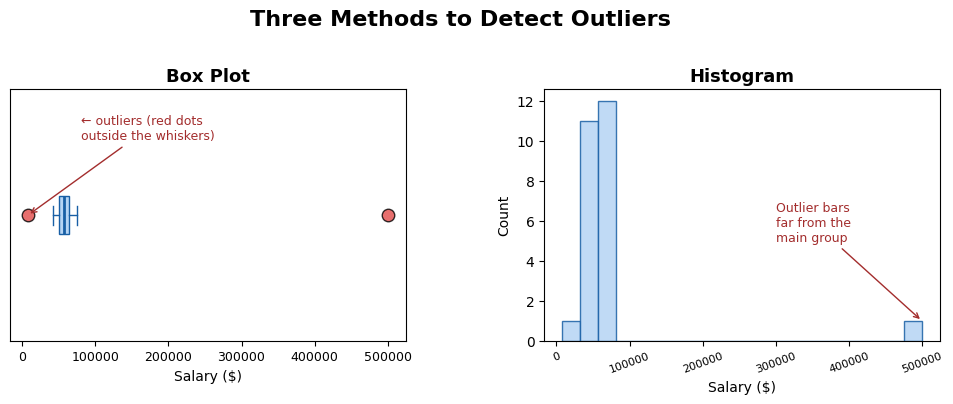

In [3]:
# ============================================================
#  METHOD 1 — Visualization (always start here!)
# ============================================================
 
fig = plt.figure(figsize=(12, 8))
fig.suptitle("Three Methods to Detect Outliers", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
 
 
# --- 1a. Box Plot ---
ax1 = fig.add_subplot(gs[0, 0])
bp = ax1.boxplot(data, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
                 medianprops=dict(color="#185FA5", linewidth=2),
                 flierprops=dict(marker="o", color="#E24B4A", markersize=9,
                                 markerfacecolor="#E24B4A", alpha=0.8),
                 whiskerprops=dict(color="#185FA5"),
                 capprops=dict(color="#185FA5"))
 
ax1.set_title("Box Plot", fontsize=13, fontweight="bold")
ax1.set_xlabel("Salary ($)")
ax1.set_yticks([])
ax1.annotate("← outliers (red dots\noutside the whiskers)",
             xy=(8000, 1), xytext=(80000, 1.3),
             arrowprops=dict(arrowstyle="->", color="#A32D2D"),
             color="#A32D2D", fontsize=9)
ax1.tick_params(axis="x", labelsize=9)
 
 
# --- 1b. Histogram ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(data, bins=20, color="#B5D4F4", edgecolor="#185FA5", alpha=0.85)
ax2.set_title("Histogram", fontsize=13, fontweight="bold")
ax2.set_xlabel("Salary ($)")
ax2.set_ylabel("Count")
ax2.annotate("Outlier bars\nfar from the\nmain group",
             xy=(500000, 1), xytext=(300000, 5),
             arrowprops=dict(arrowstyle="->", color="#A32D2D"),
             color="#A32D2D", fontsize=9)
ax2.tick_params(axis="x", labelsize=8, rotation=20)

plt.show()

As shown above, the histogram didn't show the `$8,000`, because of the bin size. When your data ranges from `$8,000` to `$500,000`, matplotlib automatically spreads the bins across that entire range. The `$8,000` value ends up sharing a bin with the `$40k–$50k` salaries, so it visually disappears into the first bar rather than standing out as an outlier.

<div style="text-align:center">
  <span style="font-size:16px; margin-right:8px;">Back to top</span>
  <a href="#StartHere" style="font-size:24px; text-decoration:none;">⬆️</a>
</div>

**Method 2 — IQR Rule**
<br>IQR = Q3 − Q1
<br>It is an outlier if: value < Q1 − 1.5×IQR or value > Q3 + 1.5×IQR

<img src="images/boxplots.jpg" width="600" height="700">

In [4]:
# ============================================================
#  METHOD 2 — IQR Rule (most beginner-friendly formula)
# ============================================================

# Step 1: Calculate IQR boundaries:
Q1  = data.quantile(0.25)   # 25th percentile
Q3  = data.quantile(0.75)   # 75th percentile
IQR = Q3 - Q1               # Interquartile Range
 
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
 
iqr_outliers = data[(data < lower_fence) | (data > upper_fence)]
iqr_normal   = data[(data >= lower_fence) & (data <= upper_fence)]
 
print("=" * 50)
print("METHOD 2 — IQR Rule")
print(f"  Q1                   : ${Q1:,.0f}")
print(f"  Q3                   : ${Q3:,.0f}")
print(f"  IQR                  : ${IQR:,.0f}")
print(f"  Lower fence          : ${lower_fence:,.0f}")
print(f"  Upper fence          : ${upper_fence:,.0f}")
print(f"  Outliers             : {iqr_outliers.tolist()}")
print(f"  Data W/O Outliers    : {iqr_normal.tolist()}")
print("=" * 50)

METHOD 2 — IQR Rule
  Q1                   : $51,000
  Q3                   : $63,500
  IQR                  : $12,500
  Lower fence          : $32,250
  Upper fence          : $82,250
  Outliers             : [8000, 500000]
  Data W/O Outliers    : [42000, 45000, 47000, 48500, 50000, 51000, 52500, 53000, 54000, 55000, 56000, 57500, 58000, 59000, 60000, 61000, 62000, 63500, 65000, 67000, 70000, 72000, 75000]


`In general, the IQR method is widely considered the most reliable "all-purpose" method for checking outliers, especially during the initial data cleaning phase.`

<div style="text-align:center">
  <span style="font-size:16px; margin-right:8px;">Back to top</span>
  <a href="#StartHere" style="font-size:24px; text-decoration:none;">⬆️</a>
</div>

**Method 3 — Z-Score**
<br>Measures how many standard deviations a point is from the mean
<br>Rule of thumb: |Z| > 3 → likely an outlier
<br>Formula: Z = (value − mean) / std

In [5]:
# ============================================================
#  METHOD 3 — Z-Score
# ============================================================

# Calculate the Z-Score:
# How many std deviations from the mean?
mean   = data.mean()
std    = data.std()

# zscores = (data - mean) / std

# or

z_scores = stats.zscore(data)
 
threshold = 3
z_outliers = data[abs(z_scores) > threshold]
z_normal   = data[abs(z_scores) <= threshold]

# Note: We use np.abs() (absolute value) because an outlier can be very high (positive Z-score) or very low (negative Z-score).
# By taking the absolute value, we can check if the result is > 3.
 
print("METHOD 3 — Z-Score")
print(f"  Mean        : ${mean:,.0f}")
print(f"  Std Dev     : ${std:,.0f}")
print(f"  Threshold   : |Z| > {threshold}")
print(f"  Outliers    : {z_outliers.tolist()}")
print("=" * 50)

METHOD 3 — Z-Score
  Mean        : $73,280
  Std Dev     : $89,833
  Threshold   : |Z| > 3
  Outliers    : [500000]


**Why is the `$8000` salary not detected as an outlier when the Z-Score method is used?**
<br>The Z-Score missed `$8,000` because of a mathematical trap called ***masking***.

**Here's what happened step by step:**
<br>The `$500,000` value pulled the mean way up to `$73,280` — far above what most employees earn. It also inflated the standard deviation to `$89,833`. Now, when Z-Score evaluates the $8,000 value:

`Z = (8,000 − 73,280) / 89,833 = −0.73`

A Z-Score of −0.73 is well within the normal range (threshold is ±3), so Z-Score finds nothing wrong here, even though $8,000 is clearly an outlier.


**The Solution is to use the Modified Z-Score or Robust Z-Score:**

In [6]:
# Modified Z-Score
# Use the median instead of the mean
median    = data.median()
MAD       = (data - median).abs().median()   # Median Absolute Deviation

# The Robust Z-Score formula is defined as:
z_robust  = 0.6745 * (data - median) / MAD  # scaled to match std Z-score

threshold = 3
z_out_rob = data[abs(z_robust) > threshold]
 
print("=" * 55)
print(f"  Robust Z-Score    — median: ${median:,.0f}, MAD: ${MAD:,.0f}")
print(f"  Outliers found    : {z_out_rob.tolist()}")
print("=" * 55)

  Robust Z-Score    — median: $57,500, MAD: $6,500
  Outliers found    : [8000, 500000]


**Note:**
- The Standard Z-Score is appropriate for normally distributed datasets where the mean and standard deviation accurately reflect the central tendency and variance.
- Conversely, when data exhibits significant skewness or contains extreme anomalies, the Modified Z-Score should be utilized; its reliance on the median and Median Absolute Deviation (MAD) ensures the metric remains robust against outlier distortion.

**Summary:**
<br>There's no single best method. The right choice depends on your data and situation.
<br>Start with a box plot to see the problem, use IQR to detect it reliably, and confirm with Z-Score or Modified Z-Score.

<div style="text-align:center">
  <span style="font-size:16px; margin-right:8px;">Back to top</span>
  <a href="#StartHere" style="font-size:24px; text-decoration:none;">⬆️</a>
</div>

**Other Outlier Detection Methods you can check on your own:**
- Mahalanobis Distance: Best for Multivariate data.
- Local Outlier Factor (LOF): Best for Datasets where clusters have varying densities. A point might be considered an outlier relative to a dense cluster, but perfectly normal relative to a sparse cluster.
- Machine Learning Methods:
  - Isolation Forest (iForest): Best for high-dimensional data and large datasets.
    <br>It is highly efficient and one of the most popular algorithms for detecting production fraud (the model is actively being used in the real world to detect fraud).
    <br>Because frauds are rare and distinct, the Isolation Forest flags them as outliers.
  - One-Class SVM (Support Vector Machine): Best for Novelty detection when you have a lot of clean data for training, but very few examples of what an outlier actually looks like.

**Diagnose the Outlier (Why does it exist?)**

**1. Artificial Outliers (Errors)**
<br>These data points are fundamentally incorrect.
<br>Examples:
<br>A human typing error (Age = 250), a data corruption glitch (Income = -9999), or a faulty sensor reading.
<br>The Rule: Remove or Impute.
- Remove them if the dataset is large, where losing a few rows won't hurt your sample size.
  <br>Warning: Never drop more than 1–5% of your total dataset, or you risk losing important patterns.

- Impute: If an outlier is clearly an error, but your dataset is too small to delete the row, you replace the outlier value with a placeholder metric.
  <br>Use the Median, not the mean. Because the mean is heavily affected by outliers, replacing a bad data point with the median ensures you are using a truly representative "middle" value.

**2. Natural Outliers (True Extremes)**
<br>These are 100% real, accurate data points, but they are just very rare.
<br>Examples:
<br>A CEO salary, or in the e-commerce, a massive traffic spike on Black Friday.
<br>The Rule: Keep, Cap, or Transform. If you delete these, your model will never learn how to handle extreme real-world scenarios.

a. Winsorization / Capping (For Natural Outliers):
<br>Instead of deleting the data point, you "cap" it at a certain percentile threshold (usually the 1st and 99th percentiles).
Example: If your 99th percentile for income is `$200,000`, a natural outlier earning `$5,000,000` is automatically rewritten as `$200,000.`

Why it works:
<br>The row remains in the dataset, but during model training, the extreme value will be neutralized to prevent it from distorting the learned weights.

b. Log Transformation (For Highly Skewed Data):
If your dataset naturally contains huge outliers (like financial data or population sizes), you can apply a mathematical function like a Log Transformation ($\log(x)$) or Box-Cox to the entire column.

Why it works:
<br>It mathematically compresses the distance between your normal data and your outliers. It pulls the extreme outliers closer to the center, transforming a highly skewed distribution into a clean bell curve that machine learning models love.

Different machine learning algorithms handle outliers differently. You should tailor your strategy to the specific model you plan to train:

|Machine Learning Model|Sensitivity to Outliers|
|------|------|
|Linear / Logistic Regression|🔴 Highly Sensitive|
|Neural Networks (Deep Learning)|🔴 Highly Sensitive|
|K-Means Clustering / KNN|🔴 Highly Sensitive|
|Tree-Based Models (Random Forest, XGBoost)|🟢 Robust / Insensitive|

##### **Back to:**
  - [Handle Missing Values](#missing_data)
  - [Remove Duplicates](#dup)
  - [Handle Outliers](#out)